In [2]:
import pandas as pd # for uploading the data
import numpy as np # for calculations
import re # for data cleaning
import nltk # for preprocessing
import matplotlib.pyplot as plt # for
from nltk.corpus import stopwords # to remove the unnecesary words
from nltk.tokenize import word_tokenize
from nltk.sentiment import SentimentIntensityAnalyzer
from collections import Counter
from wordcloud import WordCloud # To visualize the word

In [3]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\deeks\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [4]:
data={
    "Review":[
    "The film was absolutely fantastic with a gripping story and exceptional acting by the entire cast.",
    "I was bored throughout the movie because the plot was predictable and the pacing was too slow.",
    "The cinematography was beautiful, but the story was just average and lacked excitement.",
    "The comedy scenes made me laugh a lot, and the actors had excellent chemistry.",
    "The ending was rushed and left many important questions unanswered.",
    "It was a decent watch with good performances, although the screenplay could have been better.",
    "The action sequences were breathtaking, and the background music added great energy to every scene.",
    "The characters were poorly developed, making it difficult to connect with the story.",
    "The movie was neither good nor bad; it was simply an average one-time watch.",
    "I really enjoyed the emotional moments, and the direction was outstanding from start to finish.",
    "The visual effects were impressive, but the weak storyline made the film forgettable.",
    "The suspense kept me engaged until the final scene, making it one of the best thrillers I've watched.",
    "The dialogues felt unnatural, and the performances were disappointing despite a strong cast.",
    "The web series had an interesting concept but became repetitive in the middle episodes.",
    "Overall, the movie delivered an entertaining experience with memorable performances and a satisfying ending."

    ]
}

df=pd.DataFrame(data)
print("Coustomer Reviews Dataset")
print(df.head(5))


Coustomer Reviews Dataset
                                              Review
0  The film was absolutely fantastic with a gripp...
1  I was bored throughout the movie because the p...
2  The cinematography was beautiful, but the stor...
3  The comedy scenes made me laugh a lot, and the...
4  The ending was rushed and left many important ...


In [5]:
stop_words=set(stopwords.words('english'))

def clean_text(text):

  text=text.lower()

  text=re.sub('[^a-zA-Z]'," ",text)

  words=word_tokenize(text)

  words=[word for word in words if word not in stop_words]
  print('Without stopwords',words)

  cleaned_text=" ".join(words)

  return cleaned_text

df["Cleaned_Review"]=df["Review"].apply(clean_text)

print("\nCleaned Review")
print(df[['Review','Cleaned_Review']])

Without stopwords ['film', 'absolutely', 'fantastic', 'gripping', 'story', 'exceptional', 'acting', 'entire', 'cast']
Without stopwords ['bored', 'throughout', 'movie', 'plot', 'predictable', 'pacing', 'slow']
Without stopwords ['cinematography', 'beautiful', 'story', 'average', 'lacked', 'excitement']
Without stopwords ['comedy', 'scenes', 'made', 'laugh', 'lot', 'actors', 'excellent', 'chemistry']
Without stopwords ['ending', 'rushed', 'left', 'many', 'important', 'questions', 'unanswered']
Without stopwords ['decent', 'watch', 'good', 'performances', 'although', 'screenplay', 'could', 'better']
Without stopwords ['action', 'sequences', 'breathtaking', 'background', 'music', 'added', 'great', 'energy', 'every', 'scene']
Without stopwords ['characters', 'poorly', 'developed', 'making', 'difficult', 'connect', 'story']
Without stopwords ['movie', 'neither', 'good', 'bad', 'simply', 'average', 'one', 'time', 'watch']
Without stopwords ['really', 'enjoyed', 'emotional', 'moments', 'direc

In [6]:
sia=SentimentIntensityAnalyzer()
def analyze_sentiment(review):
  score = sia.polarity_scores(review)
  compound=score['compound']
  if compound >=0.05:
    return "Positive"
  elif compound <=-0.05:
    return "Negative"
  else:
    return "Neutral"

  df['Sentiment']=df['Cleaned_Review'].apply(analyze_sentiment)

  print("\nSentiment Analysis Result")
  print(df[['Review','Sentiment']])

In [7]:
all_words="".join(df['Cleaned_Review'])

word_list=all_words.split()
word_freq=Counter(word_list)

print("\nTop 10 Common Keywords")
print(word_freq.most_common(10))


Top 10 Common Keywords
[('performances', 3), ('film', 2), ('story', 2), ('movie', 2), ('average', 2), ('made', 2), ('good', 2), ('making', 2), ('one', 2), ('absolutely', 1)]


In [8]:
df['Sentiment'] = df['Cleaned_Review'].apply(analyze_sentiment)
negative_reviews = df[df['Sentiment'] =='Negative']   # Row filter
negative_words =' '.join(negative_reviews['Cleaned_Review'])

negative_word_list=negative_words.split()
complaint_freq=Counter(negative_word_list)

print("\nMost Common Complaint Keywords")
print(complaint_freq.most_common(10))


Most Common Complaint Keywords
[('bored', 1), ('throughout', 1), ('movie', 1), ('plot', 1), ('predictable', 1), ('pacing', 1), ('slow', 1), ('characters', 1), ('poorly', 1), ('developed', 1)]


In [9]:
sentiment_counts=df['Sentiment'].value_counts()
sentiment_counts

Sentiment
Positive    12
Negative     3
Name: count, dtype: int64

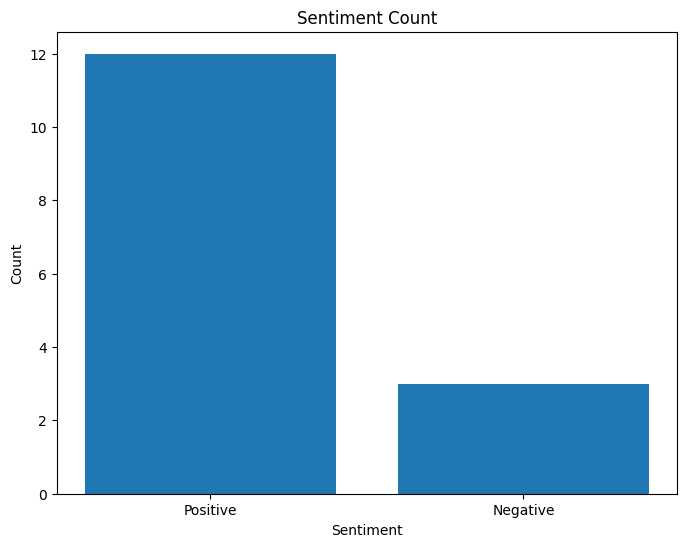

In [10]:
sentiment_counts=df['Sentiment'].value_counts()
plt.figure(figsize=(8,6))
plt.bar(sentiment_counts.index,sentiment_counts.values)
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Sentiment Count')
plt.show()

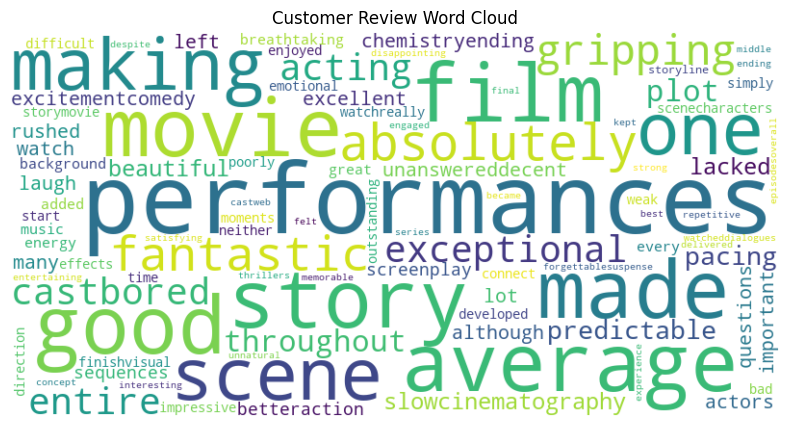

In [11]:
wordcloud=WordCloud(
    width=800,
    height=400,
    background_color='white'
    ).generate(all_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud,interpolation='bilinear')
plt.axis('off')
plt.title('Customer Review Word Cloud')
plt.show()